# Quantum Support Vector Machine (QSVM) — Phishing URL Detection

This notebook implements a **Quantum Support Vector Machine** classifier using PennyLane + scikit-learn.
Based on Havlíček et al., *Nature* 2019 — "Supervised learning with quantum-enhanced feature spaces."

---

## Algorithm Overview

**Quantum Kernel:**
$$K(x_i, x_j) = |\langle\varphi(x_i)|\varphi(x_j)\rangle|^2$$

1. Apply IQP feature map $\varphi(x_i)$ to prepare $|\varphi(x_i)\rangle$
2. Apply adjoint IQP feature map of $\varphi(x_j)$
3. Measure $P(|0\ldots0\rangle)$ = quantum kernel value $K(x_i, x_j)$
4. Build $K_{\text{train}}$ ($n_{\text{train}} \times n_{\text{train}}$) — fit `SVC(kernel='precomputed')`
5. Build $K_{\text{test}}$ ($n_{\text{test}} \times n_{\text{train}}$) — predict

---

## IQP Feature Map

The **Instantaneous Quantum Polynomial (IQP) feature map** is more expressive than simple angle encoding.
Each repetition applies:

- **Layer 1** — Hadamard + single-qubit phase: $H_i \cdot RZ(x_i)$ on each qubit $i$
- **Layer 2** — ZZ interactions (nearest-neighbor): $CNOT_{i,i+1} \cdot RZ(x_i \cdot x_{i+1}) \cdot CNOT_{i,i+1}$ for each pair $(i, i+1)$

The cross-feature products $x_i \cdot x_{i+1}$ in the ZZ interactions create feature correlations that are
hard to simulate classically, giving the quantum kernel potential advantage over classical RBF.

---

## Key Design Decisions

| Choice | Value | Reason |
|--------|-------|--------|
| Feature map | IQP (Hadamard + ZZ) | More expressive than simple angle encoding |
| n_qubits | 4 | Maps 1:1 to PCA components |
| n_reps | 2 | Sufficient expressibility; avoids circuit depth issues |
| SVM kernel | precomputed | Classical SVC optimizes margin using quantum kernel |
| QSVM train size | 500 | O(n²) kernel computation — feasible on laptop |
| SVM C | 1.0 | Standard regularization |

---

## Data Pipeline Summary

```
Raw URL → TF-IDF (50k features) → TruncatedSVD (50-dim)
       ↘ 6 URL features ↗
hstack → StandardScaler → PCA (4-dim) → MinMaxScaler [0, π]
→ IQP quantum kernel → SVC(kernel='precomputed')
```

## 1. Imports & CONFIG

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from tqdm import tqdm

from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.45.0


In [2]:
CONFIG = {
    "data_path":        "../preprocessing-dataset/processed_data.csv",
    "result_dir":       "result",
    "text_column":      "processed_text",
    "label_column":     "Label",
    "url_column":       "URL",
    "sample_size":      5000,
    "test_size":        0.2,
    "random_state":     42,
    "svd_components":   50,
    "n_pca_components": 4,
    "n_qubits":         4,
    "n_reps":           2,
    "qsvm_train_size":  500,
    "C":                1.0,
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)
print("Config loaded. Result dir ready.")

Config loaded. Result dir ready.


## 2. Load & Sample Data

Load the processed CSV and take a stratified sample of 5 000 rows.

In [3]:
df_full = pd.read_csv(CONFIG["data_path"])
print(f"Full dataset shape: {df_full.shape}")

df, _ = train_test_split(
    df_full,
    train_size=CONFIG["sample_size"],
    random_state=CONFIG["random_state"],
    stratify=df_full[CONFIG["label_column"]],
)
df = df.reset_index(drop=True)

print(f"Sampled shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")
df.head()

Full dataset shape: (549346, 3)
Sampled shape: (5000, 3)
Label distribution:
Label
good    3576
bad     1424
Name: count, dtype: int64


,URL,Label,processed_text
0,goldcoast.com.au/article/2011/11/02/362521_gol...,good,goldcoast com au articl 2011 11 02 362521 gold...
1,nypost.com/p/news/local/port_authority_boss_ch...,good,nypost com p news local port author boss chris...
2,yelp.ca/biz/redpath-sugar-museum-toronto,good,yelp ca biz redpath sugar museum toronto
3,theaircanadacentre.com/about/,good,theaircanadacentr com about
4,evri.com/organization/cinepop-0x2ff47,good,evri com organ cinepop 0x2ff47


## 3. URL Feature Engineering

Extract 6 handcrafted features from raw URL strings before the train/test split.

In [4]:
def extract_url_features(url: str) -> list:
    """Extract 6 numeric features from a raw URL string.

    Args:
        url: Raw URL string.

    Returns:
        List of [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth].
    """
    return [
        len(url),
        url.count("."),
        sum(c.isdigit() for c in url),
        sum(c in "@-_=?&" for c in url),
        1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0,
        max(0, len(url.split("/")[2].split(".")) - 2) if "//" in url else 0,
    ]


url_features = np.array(
    [extract_url_features(str(u)) for u in df[CONFIG["url_column"]].fillna("")]
)
print(f"URL feature matrix shape: {url_features.shape}")
print("Columns: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth")

URL feature matrix shape: (5000, 6)
Columns: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth


## 4. Train/Test Split

80/20 stratified split. All scalers and transformers are fitted on train only.

In [5]:
y = df[CONFIG["label_column"]].values
text_col = df[CONFIG["text_column"]].fillna("").astype(str).values

(
    text_train, text_test,
    url_feat_train, url_feat_test,
    y_train, y_test,
) = train_test_split(
    text_col, url_features, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

print(f"Train samples: {len(text_train)}")
print(f"Test samples:  {len(text_test)}")

Train samples: 4000
Test samples:  1000


## 5. TF-IDF Vectorization

Convert cleaned URL text to TF-IDF features. Fit on train only.

In [6]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_features=50000,
)
x_train_tfidf = tfidf.fit_transform(text_train)
x_test_tfidf  = tfidf.transform(text_test)

print(f"TF-IDF train shape: {x_train_tfidf.shape}")
print(f"TF-IDF test shape:  {x_test_tfidf.shape}")

TF-IDF train shape: (4000, 2303)
TF-IDF test shape:  (1000, 2303)


## 6. TruncatedSVD Dimensionality Reduction

Reduce sparse TF-IDF matrix to 50 dense dimensions. Fit on train only.

In [7]:
svd = TruncatedSVD(
    n_components=CONFIG["svd_components"],
    random_state=CONFIG["random_state"],
)
x_train_svd = svd.fit_transform(x_train_tfidf)
x_test_svd  = svd.transform(x_test_tfidf)

explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD dims: {x_train_svd.shape[1]}")
print(f"Explained variance: {explained_var:.2%}")

SVD dims: 50
Explained variance: 33.85%


## 7. Combine Features + StandardScaler

Stack SVD features and 6 URL features, then standardize. Fit on train only.

In [8]:
x_train_combined = np.hstack([x_train_svd, url_feat_train])
x_test_combined  = np.hstack([x_test_svd,  url_feat_test])

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_combined)
x_test_scaled  = scaler.transform(x_test_combined)

print(f"Combined + scaled train shape: {x_train_scaled.shape}")
print(f"Combined + scaled test shape:  {x_test_scaled.shape}")

Combined + scaled train shape: (4000, 56)
Combined + scaled test shape:  (1000, 56)


## 8. PCA to 4 Dimensions

Reduce to 4 components — one per qubit. Fit on train only.

In [9]:
pca = PCA(
    n_components=CONFIG["n_pca_components"],
    random_state=CONFIG["random_state"],
)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca  = pca.transform(x_test_scaled)

explained_pca = pca.explained_variance_ratio_.sum()
print(f"PCA output shape (train): {x_train_pca.shape}")
print(f"PCA explained variance:   {explained_pca:.2%}")

PCA output shape (train): (4000, 4)
PCA explained variance:   12.76%


## 9. Normalize to [0, π]

Scale PCA outputs to [0, π] so they can be used as rotation angles in the IQP feature map.
MinMaxScaler fitted on train only — **do not** apply a second StandardScaler after this step.

In [10]:
angle_scaler = MinMaxScaler(feature_range=(0, np.pi))
x_train_angles = angle_scaler.fit_transform(x_train_pca)
x_test_angles  = angle_scaler.transform(x_test_pca)

print(f"Angle-encoded train range: [{x_train_angles.min():.4f}, {x_train_angles.max():.4f}]")
print(f"Angle-encoded test range:  [{x_test_angles.min():.4f}, {x_test_angles.max():.4f}]")
print(f"Shape: {x_train_angles.shape}  (samples × qubits)")

Angle-encoded train range: [0.0000, 3.1416]
Angle-encoded test range:  [-0.0598, 3.1389]
Shape: (4000, 4)  (samples × qubits)


## 10. Quantum Device, IQP Feature Map & Kernel Circuit

The **IQP feature map** encodes classical data into a quantum state:
- **Hadamard** puts each qubit into superposition
- **RZ(x_i)** applies a single-qubit phase proportional to feature $x_i$
- **ZZ interactions** via $CNOT \cdot RZ(x_i \cdot x_{i+1}) \cdot CNOT$ encode pairwise correlations

The quantum kernel is computed as:
$$K(x_1, x_2) = P(|0\ldots0\rangle) = |\langle\varphi(x_1)|\varphi(x_2)\rangle|^2$$

by encoding $x_1$, applying the adjoint encoding of $x_2$, then measuring.

In [11]:
dev = qml.device("default.qubit", wires=CONFIG["n_qubits"])


def iqp_feature_map(x: np.ndarray, n_reps: int, n_qubits: int) -> None:
    """Apply IQP feature map in-place on the quantum device.

    Args:
        x: Input vector, shape (n_qubits,), values in [0, π].
        n_reps: Number of repetitions of the feature map layer.
        n_qubits: Number of qubits.
    """
    for _ in range(n_reps):
        # Layer 1: Hadamard + single-qubit RZ
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(x[i], wires=i)
        # Layer 2: ZZ interactions (nearest-neighbor pairs)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
            qml.RZ(x[i] * x[i + 1], wires=i + 1)
            qml.CNOT(wires=[i, i + 1])


@qml.qnode(dev)
def quantum_kernel_circuit(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """Compute quantum kernel value K(x1, x2) = |<φ(x1)|φ(x2)>|².

    Args:
        x1: First sample, shape (n_qubits,), values in [0, π].
        x2: Second sample, shape (n_qubits,), values in [0, π].

    Returns:
        Probability distribution over all 2^n_qubits basis states.
        probs[0] = P(|0...0⟩) = K(x1, x2).
    """
    n_qubits = CONFIG["n_qubits"]
    n_reps   = CONFIG["n_reps"]
    iqp_feature_map(x1, n_reps, n_qubits)
    qml.adjoint(iqp_feature_map)(x2, n_reps, n_qubits)
    return qml.probs(wires=range(n_qubits))


def quantum_kernel(x1: np.ndarray, x2: np.ndarray) -> float:
    """Return the scalar quantum kernel value K(x1, x2).

    Args:
        x1: First sample.
        x2: Second sample.

    Returns:
        Kernel value in [0, 1].
    """
    probs = quantum_kernel_circuit(x1, x2)
    return float(probs[0])


# Sanity check
k_self  = quantum_kernel(x_train_angles[0], x_train_angles[0])
k_cross = quantum_kernel(x_train_angles[0], x_train_angles[1])
print(f"Self-kernel  (should be ~1.0): {k_self:.6f}")
print(f"Cross-kernel sample 0 vs 1:   {k_cross:.6f}")
print("\nCircuit diagram:")
print(qml.draw(quantum_kernel_circuit)(x_train_angles[0], x_train_angles[1]))

Self-kernel  (should be ~1.0): 1.000000
Cross-kernel sample 0 vs 1:   0.797557

Circuit diagram:
0: ──H──RZ(0.26)─╭●───────────╭●──H──RZ(0.26)─────────────────╭●───────────╭●────────── ···
1: ──H──RZ(1.15)─╰X──RZ(0.30)─╰X─╭●───────────╭●──H──RZ(1.15)─╰X──RZ(0.30)─╰X────────╭● ···
2: ──H──RZ(0.73)─────────────────╰X──RZ(0.84)─╰X─╭●───────────╭●──H─────────RZ(0.73)─╰X ···
3: ──H──RZ(1.50)─────────────────────────────────╰X──RZ(1.10)─╰X──H─────────RZ(1.50)─── ···

0: ··· ───────────────────────────────────────────────────────────────────────────╭X†─────── ···
1: ··· ───────────╭●────────────────────────────────────╭X†───────────────────╭X†─╰X†─────── ···
2: ··· ──RZ(0.84)─╰X─╭●───────────╭●─╭X†────────────╭X†─╰X†─────────RZ(1.04)†─╰X†──RZ(0.67)† ···
3: ··· ──────────────╰X──RZ(1.10)─╰X─╰X†──RZ(0.69)†─╰X†──RZ(1.03)†──H†────────────────────── ···

0: ··· ────────────╭X†──RZ(0.14)†──H†───────────────────────────╭X†───────────────────╭X† ···
1: ··· ──RZ(0.22)†─╰X†──RZ(1.55)†──H†─╭X†──────────

## 11. Subsample Training Set for QSVM

Kernel computation is O(n²). Use a stratified subsample of 500 training samples
to keep K_train (500 × 500) computationally feasible (~20–35 min total).

In [12]:
idx_qsvm, _ = train_test_split(
    np.arange(len(x_train_angles)),
    train_size=CONFIG["qsvm_train_size"],
    random_state=CONFIG["random_state"],
    stratify=y_train,
)

x_qsvm_train = x_train_angles[idx_qsvm]   # (500, 4)
y_qsvm_train = y_train[idx_qsvm]           # (500,)

print(f"QSVM train samples: {x_qsvm_train.shape[0]}")
print(f"Test samples:       {x_test_angles.shape[0]}")
print(f"Train label dist:   {dict(zip(*np.unique(y_qsvm_train, return_counts=True)))}")

QSVM train samples: 500
Test samples:       1000
Train label dist:   {'bad': np.int64(142), 'good': np.int64(358)}


## 12. Compute K_train (500 × 500, Symmetric)

K_train is symmetric: K[i,j] = K[j,i]. Only the upper triangle is computed, halving the cost.
Result cached to `result/kernel_matrix_train.npy` — recomputing from scratch takes ~15 min.

In [13]:
def compute_kernel_matrix(
    x_query: np.ndarray,
    x_train: np.ndarray,
    desc: str = "Kernel",
    symmetric: bool = False,
) -> np.ndarray:
    """Compute pairwise quantum kernel matrix.

    Args:
        x_query: Query samples, shape (n_query, n_qubits).
        x_train: Training samples, shape (n_train, n_qubits).
        desc: tqdm progress bar label.
        symmetric: If True, exploit symmetry K[i,j]=K[j,i] for speed.

    Returns:
        Kernel matrix of shape (n_query, n_train), values in [0, 1].
    """
    n_query = x_query.shape[0]
    n_train = x_train.shape[0]
    K = np.zeros((n_query, n_train), dtype=np.float32)

    if symmetric:
        for i in tqdm(range(n_query), desc=desc, unit="row"):
            for j in range(i, n_train):
                val = quantum_kernel(x_query[i], x_train[j])
                K[i, j] = val
                K[j, i] = val
    else:
        for i in tqdm(range(n_query), desc=desc, unit="row"):
            for j in range(n_train):
                K[i, j] = quantum_kernel(x_query[i], x_train[j])

    return K


k_train_path = os.path.join(CONFIG["result_dir"], "kernel_matrix_train.npy")

if os.path.exists(k_train_path):
    print("Loading cached K_train...")
    K_train = np.load(k_train_path)
else:
    print("Computing K_train (500 × 500, symmetric)...")
    K_train = compute_kernel_matrix(
        x_qsvm_train, x_qsvm_train, desc="K_train", symmetric=True
    )
    np.save(k_train_path, K_train)
    print(f"K_train saved → {k_train_path}")

print(f"K_train shape: {K_train.shape}")
print(f"K_train diagonal mean (should be ~1.0): {np.diag(K_train).mean():.6f}")

Computing K_train (500 × 500, symmetric)...


K_train: 100%|██████████| 500/500 [1:10:48<00:00,  8.50s/row]

K_train saved → result\kernel_matrix_train.npy
K_train shape: (500, 500)
K_train diagonal mean (should be ~1.0): 1.000000


## 13. Compute K_test (1000 × 500)

K_test[i, j] = K(x_test[i], x_train[j]) — shape must be (n_test, n_train).
This is **not** symmetric. Cached to `result/kernel_matrix_test.npy`.

In [14]:
k_test_path = os.path.join(CONFIG["result_dir"], "kernel_matrix_test.npy")

if os.path.exists(k_test_path):
    print("Loading cached K_test...")
    K_test = np.load(k_test_path)
else:
    print("Computing K_test (1000 × 500)...")
    K_test = compute_kernel_matrix(
        x_test_angles, x_qsvm_train, desc="K_test", symmetric=False
    )
    np.save(k_test_path, K_test)
    print(f"K_test saved → {k_test_path}")

print(f"K_test shape: {K_test.shape}")

Computing K_test (1000 × 500)...


K_test: 100%|██████████| 1000/1000 [2:18:04<00:00,  8.28s/row] 

K_test saved → result\kernel_matrix_test.npy
K_test shape: (1000, 500)


## 14. Train SVC with Precomputed Quantum Kernel

`SVC(kernel='precomputed')` expects K_train shape (n_train, n_train) for `.fit()`
and K_test shape (n_test, n_train) for `.predict()` — exactly what we built.

In [15]:
svm = SVC(
    kernel="precomputed",
    C=CONFIG["C"],
    random_state=CONFIG["random_state"],
)
svm.fit(K_train, y_qsvm_train)

print(f"SVC trained. Number of support vectors: {svm.n_support_.sum()}")
print(f"Support vector counts per class: {dict(zip(svm.classes_, svm.n_support_))}")

SVC trained. Number of support vectors: 256
Support vector counts per class: {'bad': np.int32(128), 'good': np.int32(128)}


## 15. Evaluate on Test Set

Predict using K_test (1000 × 500) — each row gives the kernel values between one test sample
and all 500 QSVM training samples. SVC uses these to compute the decision function.

In [16]:
y_pred   = svm.predict(K_test)
test_acc = accuracy_score(y_test, y_pred)
report   = classification_report(y_test, y_pred, target_names=["bad", "good"])

print(f"Test Accuracy: {test_acc:.4f}\n")
print(report)

Test Accuracy: 0.7690

              precision    recall  f1-score   support

         bad       0.91      0.21      0.34       285
        good       0.76      0.99      0.86       715

    accuracy                           0.77      1000
   macro avg       0.83      0.60      0.60      1000
weighted avg       0.80      0.77      0.71      1000



## 16. Plot & Save Confusion Matrix

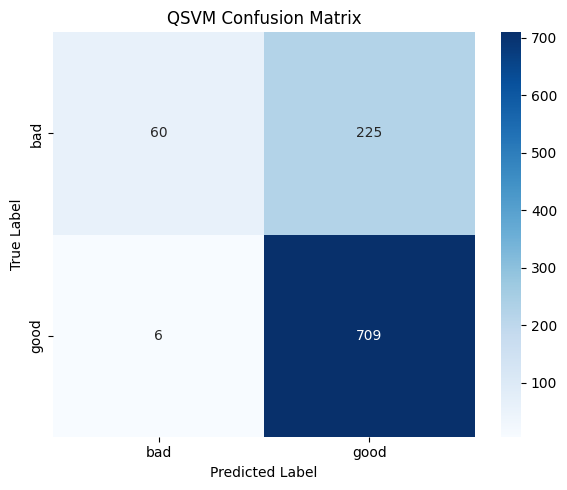

Confusion matrix saved → result\confusion_matrix_qsvm.png


In [17]:
cm     = confusion_matrix(y_test, y_pred, labels=["bad", "good"])
labels = ["bad", "good"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_title("QSVM Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_qsvm.png")
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix saved → {cm_path}")

## 17. Save Classification Report

In [18]:
report_path = os.path.join(CONFIG["result_dir"], "classification_report_qsvm.txt")
with open(report_path, "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n\n")
    f.write(report)

print(f"Classification report saved → {report_path}")

Classification report saved → result\classification_report_qsvm.txt


## 18. Summary

In [19]:
print("=" * 58)
print("  QSVM — Phishing URL Detection — Final Summary")
print("=" * 58)
print("\n[Config]")
for key, val in CONFIG.items():
    print(f"  {key:<22}: {val}")
print("\n[Pipeline]")
print(f"  TF-IDF max_features      : 50 000")
print(f"  SVD explained variance   : {svd.explained_variance_ratio_.sum():.2%}")
print(f"  PCA explained variance   : {pca.explained_variance_ratio_.sum():.2%}")
print(f"  Angle range              : [0, π]")
print("\n[QSVM]")
print(f"  n_qubits                 : {CONFIG['n_qubits']}")
print(f"  n_reps (IQP)             : {CONFIG['n_reps']}")
print(f"  Feature map              : IQP (Hadamard + RZ + ZZ interactions)")
print(f"  Kernel                   : |<φ(x1)|φ(x2)>|²")
print(f"  QSVM train samples       : {x_qsvm_train.shape[0]}")
print(f"  K_train shape            : {K_train.shape}")
print(f"  K_test shape             : {K_test.shape}")
print(f"  SVM C                    : {CONFIG['C']}")
print(f"  Support vectors          : {svm.n_support_.sum()}")
print("\n[Results]")
print(f"  Test accuracy            : {test_acc:.4f}")
print("\n[Saved files]")
print(f"  {report_path}")
print(f"  {cm_path}")
print(f"  {k_train_path}")
print(f"  {k_test_path}")
print("=" * 58)

  QSVM — Phishing URL Detection — Final Summary

[Config]
  data_path             : ../preprocessing-dataset/processed_data.csv
  result_dir            : result
  text_column           : processed_text
  label_column          : Label
  url_column            : URL
  sample_size           : 5000
  test_size             : 0.2
  random_state          : 42
  svd_components        : 50
  n_pca_components      : 4
  n_qubits              : 4
  n_reps                : 2
  qsvm_train_size       : 500
  C                     : 1.0

[Pipeline]
  TF-IDF max_features      : 50 000
  SVD explained variance   : 33.85%
  PCA explained variance   : 12.76%
  Angle range              : [0, π]

[QSVM]
  n_qubits                 : 4
  n_reps (IQP)             : 2
  Feature map              : IQP (Hadamard + RZ + ZZ interactions)
  Kernel                   : |<φ(x1)|φ(x2)>|²
  QSVM train samples       : 500
  K_train shape            : (500, 500)
  K_test shape             : (1000, 500)
  SVM C             